In [16]:
# Cell 1: Install & imports (Kaggle generally already has torch; remove pip if not needed)
# (Uncomment if torch or torchvision missing in Kaggle environment)
# !pip install -q torch torchvision tqdm scikit-learn

import os, re, shutil, json
from pathlib import Path
from collections import defaultdict, Counter
from glob import glob
import numpy as np
from PIL import Image
from tqdm import tqdm
import random

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

from sklearn.metrics import roc_auc_score, accuracy_score, precision_recall_fscore_support


In [17]:
# Cell 2: Edit these paths for your Kaggle notebook
# IMPORTANT: /kaggle/input is read-only; we'll read from it and save features to /kaggle/working
ROOT = "/kaggle/input/ucf-crime-dataset"   # <-- change to your dataset root inside /kaggle/input
# Expected structure:
# ROOT/Train/<category_name>/* (frames flat or already in subfolders)
# ROOT/Test/<category_name>/*

FEATURE_OUT = "/kaggle/working/features"   # where .npy outputs will be saved (writable)
os.makedirs(FEATURE_OUT, exist_ok=True)

SEQ_LEN = 12
STRIDE = 6
BATCH_SIZE = 8
EPOCHS = 20
LR = 1e-4
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
FRAME_EXTS = (".jpg", ".png", ".jpeg")
print("Device:", DEVICE)
print("ROOT exists:", os.path.exists(ROOT))


Device: cuda
ROOT exists: True


In [18]:
# Cell 3: Grouping heuristic function
def grouping_key_from_filename(fname):
    """
    Extract a stable video-id prefix from a filename.
    Examples:
      Abuse028_x264_1410.jpg -> Abuse028_x264
      Abuse028_1410.jpg -> Abuse028
      Abuse028x2641410.jpg -> Abuse028x264
    """
    stem = Path(fname).stem
    parts = stem.split('_')
    if parts and parts[-1].isdigit():
        prefix = '_'.join(parts[:-1]) if len(parts) > 1 else parts[0]
        return prefix
    m = re.match(r"^(.+?)(\d+)$", stem)
    if m:
        return m.group(1).rstrip('_-')
    if len(parts) > 1:
        return '_'.join(parts[:-1])
    return stem


In [19]:
# Cell 4: Build mapping for a split (Train or Test)
def build_group_map_for_split(root_split_dir):
    """
    Returns:
      group_map: dict mapping (category, group_key) -> list of full file paths (sorted)
      meta: dict with counts per (category, group_key)
    """
    group_map = defaultdict(list)
    categories = sorted([d for d in os.listdir(root_split_dir) if os.path.isdir(os.path.join(root_split_dir, d))])
    for cat in tqdm(categories, desc=f"Scanning categories in {root_split_dir}"):
        cat_dir = os.path.join(root_split_dir, cat)
        # gather all files in category (including nested subfolders)
        files = []
        # if frames are already in subfolders (one folder per video), detect that:
        subdirs = [d for d in os.listdir(cat_dir) if os.path.isdir(os.path.join(cat_dir, d))]
        if subdirs and not any(p.lower().endswith(('.jpg','.png','.jpeg')) for p in os.listdir(cat_dir)):
            # assume each subdir is already a video folder: group by folder name
            for sub in subdirs:
                subp = os.path.join(cat_dir, sub)
                imgs = sorted([os.path.join(subp, f) for f in os.listdir(subp) if f.lower().endswith(FRAME_EXTS)])
                if len(imgs) == 0:
                    continue
                key = sub  # use folder name as group key
                group_map[(cat, key)].extend(imgs)
        else:
            # flat files: group by heuristic on filename
            flat_files = sorted([f for f in os.listdir(cat_dir) if f.lower().endswith(FRAME_EXTS)])
            for f in flat_files:
                key = grouping_key_from_filename(f)
                group_map[(cat, key)].append(os.path.join(cat_dir, f))
    # Sort filenames inside each group
    for k in list(group_map.keys()):
        group_map[k] = sorted(group_map[k])
    return group_map

train_map = build_group_map_for_split(os.path.join(ROOT, "Train"))
test_map  = build_group_map_for_split(os.path.join(ROOT, "Test"))

# quick overview
print("Train grouped videos:", len(train_map))
print("Test grouped videos:", len(test_map))
# show top few groups
for (cat,key), files in list(train_map.items())[:10]:
    print(cat, key, "->", len(files), "frames, sample:", [Path(x).name for x in files[:3]])


Scanning categories in /kaggle/input/ucf-crime-dataset/Train: 100%|██████████| 14/14 [1:19:43<00:00, 341.69s/it]  
Scanning categories in /kaggle/input/ucf-crime-dataset/Test: 100%|██████████| 14/14 [06:19<00:00, 27.09s/it]

Train grouped videos: 1610
Test grouped videos: 290
Abuse Abuse001_x264 -> 273 frames, sample: ['Abuse001_x264_0.png', 'Abuse001_x264_10.png', 'Abuse001_x264_100.png']
Abuse Abuse002_x264 -> 87 frames, sample: ['Abuse002_x264_0.png', 'Abuse002_x264_10.png', 'Abuse002_x264_100.png']
Abuse Abuse003_x264 -> 370 frames, sample: ['Abuse003_x264_0.png', 'Abuse003_x264_10.png', 'Abuse003_x264_100.png']
Abuse Abuse004_x264 -> 1680 frames, sample: ['Abuse004_x264_0.png', 'Abuse004_x264_10.png', 'Abuse004_x264_100.png']
Abuse Abuse005_x264 -> 95 frames, sample: ['Abuse005_x264_0.png', 'Abuse005_x264_10.png', 'Abuse005_x264_100.png']
Abuse Abuse006_x264 -> 438 frames, sample: ['Abuse006_x264_0.png', 'Abuse006_x264_10.png', 'Abuse006_x264_100.png']
Abuse Abuse007_x264 -> 115 frames, sample: ['Abuse007_x264_0.png', 'Abuse007_x264_10.png', 'Abuse007_x264_100.png']
Abuse Abuse008_x264 -> 841 frames, sample: ['Abuse008_x264_0.png', 'Abuse008_x264_10.png', 'Abuse008_x264_100.png']
Abuse Abuse009_x264 -

In [20]:
print("done")

done


In [21]:
# Cell 5: Label rule: if category name contains 'normal' -> label 0 else 1.
def build_labels_from_group_map(group_map):
    labels = {}
    for (cat, key) in group_map.keys():
        video_name = f"{cat}__{key}"   # make unique name including category
        label = 0 if 'normal' in cat.lower() else 1
        labels[video_name] = label
    return labels

# But we also need a mapping from (cat,key) -> video_name used to name npy
def make_video_name(cat,key):
    return f"{cat}__{key}"

train_labels = build_labels_from_group_map(train_map)
test_labels  = build_labels_from_group_map(test_map)

print("Example train labels (first 8):")
list(train_labels.items())[:8]


Example train labels (first 8):


[('Abuse__Abuse001_x264', 1),
 ('Abuse__Abuse002_x264', 1),
 ('Abuse__Abuse003_x264', 1),
 ('Abuse__Abuse004_x264', 1),
 ('Abuse__Abuse005_x264', 1),
 ('Abuse__Abuse006_x264', 1),
 ('Abuse__Abuse007_x264', 1),
 ('Abuse__Abuse008_x264', 1)]

In [22]:
# Cell 6: Build feature model (ResNet50) and transform
def get_feature_model(device=DEVICE):
    model = models.resnet50(pretrained=True)
    model.fc = nn.Identity()
    model = model.to(device).eval()
    return model

feature_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

feat_model = get_feature_model()


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 218MB/s]


In [23]:
# Cell 7: Save .npy per grouped video into FEATURE_OUT/{split}/<video_name>.npy
def extract_features_from_group_map(group_map, split_name, out_root=FEATURE_OUT, model=feat_model, transform=feature_transform, device=DEVICE, overwrite=False):
    out_dir = os.path.join(out_root, split_name)
    os.makedirs(out_dir, exist_ok=True)
    for (cat,key), file_list in tqdm(group_map.items(), desc=f"Extract features {split_name}"):
        video_name = make_video_name(cat, key)
        out_path = os.path.join(out_dir, f"{video_name}.npy")
        if os.path.exists(out_path) and not overwrite:
            continue
        feats = []
        with torch.no_grad():
            for img_path in file_list:
                try:
                    img = Image.open(img_path).convert("RGB")
                except Exception as e:
                    print("skip", img_path, e); continue
                x = transform(img).unsqueeze(0).to(device)
                fvec = model(x)  # (1,2048)
                feats.append(fvec.cpu().numpy().squeeze(0))
        if len(feats) == 0:
            continue
        feats = np.stack(feats, axis=0)
        np.save(out_path, feats)

# Run feature extraction (this will take time; GPU recommended)
extract_features_from_group_map(train_map, "Train")
extract_features_from_group_map(test_map, "Test")


Extract features Test: 100%|██████████| 290/290 [29:44<00:00,  6.15s/it]  


In [24]:
EPOCHS = 5

In [25]:
# Cell 8: Dataset & collate (reads from FEATURE_OUT/{split}/*.npy)
class VideoSequenceDataset(Dataset):
    def __init__(self, npy_dir, labels_dict, seq_len=SEQ_LEN, stride=STRIDE):
        self.samples = []
        self.video_index = {}
        self.seq_len = seq_len
        files = sorted(glob(os.path.join(npy_dir, "*.npy")))
        for f in files:
            video_name = Path(f).stem
            if video_name not in labels_dict:
                # skip unknown (shouldn't happen)
                continue
            feats = np.load(f)
            T = feats.shape[0]
            starts = list(range(0, max(1, T - seq_len + 1), stride))
            for s in starts:
                seq = feats[s:s+seq_len]
                if seq.shape[0] != seq_len:
                    continue
                idx = len(self.samples)
                self.samples.append((video_name, seq.astype(np.float32), int(labels_dict[video_name])))
                self.video_index.setdefault(video_name, []).append(idx)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        video_name, seq, label = self.samples[idx]
        return torch.tensor(seq), torch.tensor(label, dtype=torch.long), video_name

def collate_fn(batch):
    seqs = torch.stack([b[0] for b in batch], dim=0)
    labels = torch.stack([b[1] for b in batch], dim=0)
    names = [b[2] for b in batch]
    return seqs, labels, names


In [26]:
# Cell 9: Build dataset & dataloaders
train_feat_dir = os.path.join(FEATURE_OUT, "Train")
test_feat_dir  = os.path.join(FEATURE_OUT, "Test")

# labels dicts keys are video_name like "abuse__Abuse028_x264"
# ensure train_labels/test_labels keys match saved npy names
print("Train label count:", len(train_labels), "Test label count:", len(test_labels))

train_ds = VideoSequenceDataset(train_feat_dir, train_labels, seq_len=SEQ_LEN, stride=STRIDE)
val_ds   = VideoSequenceDataset(test_feat_dir, test_labels,    seq_len=SEQ_LEN, stride=STRIDE)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, collate_fn=collate_fn)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, collate_fn=collate_fn)

print("Train seq samples:", len(train_ds))
print("Val seq samples:", len(val_ds))


Train label count: 1610 Test label count: 290
Train seq samples: 208802
Val seq samples: 18148


In [27]:
# Cell 10: Define BiLSTM model
class BiLSTMClassifier(nn.Module):
    def __init__(self, input_size=2048, hidden_size=512, num_layers=1, num_classes=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=num_layers, batch_first=True, bidirectional=True, dropout=dropout if num_layers>1 else 0.0)
        self.fc1 = nn.Linear(hidden_size*2, 256)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.relu(self.fc1(out))
        logits = self.fc2(out)
        return logits

model = BiLSTMClassifier(input_size=2048, hidden_size=512, num_layers=1).to(DEVICE)
print(model)


BiLSTMClassifier(
  (lstm): LSTM(2048, 512, batch_first=True, bidirectional=True)
  (fc1): Linear(in_features=1024, out_features=256, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=256, out_features=2, bias=True)
)


In [28]:
# Cell 11: training utilities and evaluation
def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
set_seed(42)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=3, factor=0.5, verbose=True)

def evaluate(model, loader, device=DEVICE):
    model.eval()
    all_seq_labels = []; all_seq_probs = []
    vid_probs = {}
    with torch.no_grad():
        for x,y,names in loader:
            x = x.to(device)
            logits = model(x)
            probs = torch.softmax(logits, dim=1)[:,1].cpu().numpy()
            labels = y.numpy().tolist()
            for i,name in enumerate(names):
                vid_probs.setdefault(name, []).append(float(probs[i]))
                all_seq_probs.append(float(probs[i]))
                all_seq_labels.append(int(labels[i]))
    seq_auc = roc_auc_score(all_seq_labels, all_seq_probs) if len(set(all_seq_labels))>1 else 0.0
    seq_pred = [1 if p>=0.5 else 0 for p in all_seq_probs]
    seq_acc = accuracy_score(all_seq_labels, seq_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(all_seq_labels, seq_pred, average='binary', zero_division=0)
    return {"seq_auc":seq_auc,"seq_acc":seq_acc,"seq_prec":prec,"seq_rec":rec,"seq_f1":f1,"vid_probs":vid_probs}

def aggregate_vid(vid_probs, label_map):
    y_true=[]; y_score=[]
    for vname, probs in vid_probs.items():
        if vname not in label_map: continue
        y_true.append(label_map[vname])
        y_score.append(float(np.mean(probs)))
    if len(y_true)==0:
        return {"vid_auc":0.0,"vid_acc":0.0,"vid_prec":0.0,"vid_rec":0.0,"vid_f1":0.0}
    vid_auc = roc_auc_score(y_true, y_score) if len(set(y_true))>1 else 0.0
    vid_pred = [1 if s>=0.5 else 0 for s in y_score]
    vid_acc = accuracy_score(y_true, vid_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, vid_pred, average='binary', zero_division=0)
    return {"vid_auc":vid_auc,"vid_acc":vid_acc,"vid_prec":prec,"vid_rec":rec,"vid_f1":f1}


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [29]:
# Cell 12: Training loop
best_val_auc = 0.0
ckpt_dir = "/kaggle/working/checkpoints"
os.makedirs(ckpt_dir, exist_ok=True)

for epoch in range(1, EPOCHS+1):
    model.train()
    running_loss = 0.0
    for x,y,_ in tqdm(train_loader, desc=f"Epoch {epoch} train"):
        x = x.to(DEVICE); y = y.to(DEVICE)
        logits = model(x)
        loss = criterion(logits, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * x.size(0)
    epoch_loss = running_loss / len(train_loader.dataset) if len(train_loader.dataset)>0 else 0.0
    val_stats = evaluate(model, val_loader, DEVICE)
    vid_eval = aggregate_vid(val_stats["vid_probs"], test_labels)
    print(f"Epoch {epoch}: Loss={epoch_loss:.4f} SeqAUC={val_stats['seq_auc']:.4f} SeqF1={val_stats['seq_f1']:.4f} | VidAUC={vid_eval['vid_auc']:.4f} VidF1={vid_eval['vid_f1']:.4f}")
    scheduler.step(vid_eval['vid_auc'])
    if vid_eval['vid_auc'] > best_val_auc:
        best_val_auc = vid_eval['vid_auc']
        torch.save({"model_state":model.state_dict(), "epoch":epoch, "vid_auc":best_val_auc}, os.path.join(ckpt_dir, "best_model.pth"))
        print("Saved best model.")
print("Training finished. Best val AUC:", best_val_auc)


Epoch 1 train: 100%|██████████| 26101/26101 [03:18<00:00, 131.54it/s]


Epoch 1: Loss=0.0850 SeqAUC=0.7938 SeqF1=0.6770 | VidAUC=0.8404 VidF1=0.7279
Saved best model.


Epoch 2 train: 100%|██████████| 26101/26101 [03:15<00:00, 133.17it/s]


Epoch 2: Loss=0.0221 SeqAUC=0.8643 SeqF1=0.6490 | VidAUC=0.8733 VidF1=0.6522
Saved best model.


Epoch 3 train: 100%|██████████| 26101/26101 [03:12<00:00, 135.27it/s]


Epoch 3: Loss=0.0138 SeqAUC=0.8486 SeqF1=0.7657 | VidAUC=0.8588 VidF1=0.7472


Epoch 4 train: 100%|██████████| 26101/26101 [03:17<00:00, 132.40it/s]


Epoch 4: Loss=0.0102 SeqAUC=0.8521 SeqF1=0.7138 | VidAUC=0.8569 VidF1=0.6942


Epoch 5 train: 100%|██████████| 26101/26101 [03:19<00:00, 131.14it/s]


Epoch 5: Loss=0.0085 SeqAUC=0.8676 SeqF1=0.7960 | VidAUC=0.8750 VidF1=0.7845
Saved best model.
Training finished. Best val AUC: 0.8749523809523808


In [31]:
ckpt_path = "/kaggle/working/checkpoints/best_model.pth"
ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)   # allow full unpickling
model.load_state_dict(ckpt["model_state"])
print("Loaded checkpoint (weights_only=False)")


Loaded checkpoint (weights_only=False)


In [32]:
# Save model weights only (recommended)
save_path = "/kaggle/working/best_model_state.pth"
torch.save(model.state_dict(), save_path)
print("Model weights saved to:", save_path)


Model weights saved to: /kaggle/working/best_model_state.pth


In [35]:
# Load model
model = BiLSTMClassifier(input_size=2048, hidden_size=512, num_layers=1, num_classes=2).to(DEVICE)

# Load weights (use state_dict if you saved that way)
state_path = "/kaggle/working/best_model_state.pth"   # adjust if needed
state_dict = torch.load(state_path, map_location=DEVICE)
model.load_state_dict(state_dict)
model.eval()
print("Model loaded from:", state_path)


Model loaded from: /kaggle/working/best_model_state.pth


In [36]:
from sklearn.metrics import classification_report, confusion_matrix

def get_video_level_predictions(model, feat_dir, labels_dict, seq_len=SEQ_LEN, stride=STRIDE):
    names, y_true, y_score = [], [], []
    for f in sorted(glob(os.path.join(feat_dir, "*.npy"))):
        vname = Path(f).stem
        if vname not in labels_dict:
            continue
        feats = np.load(f)
        # make sequences
        seqs = []
        for s in range(0, max(1, feats.shape[0]-seq_len+1), stride):
            seq = feats[s:s+seq_len]
            if seq.shape[0] != seq_len: continue
            seqs.append(seq.astype(np.float32))
        if len(seqs) == 0: continue
        x = torch.tensor(np.stack(seqs), dtype=torch.float32).to(DEVICE)
        with torch.no_grad():
            probs = torch.softmax(model(x), dim=1)[:,1].cpu().numpy()
        # aggregate score
        score = float(np.mean(probs))
        names.append(vname)
        y_true.append(labels_dict[vname])
        y_score.append(score)
    return names, np.array(y_true), np.array(y_score)

names, y_true, y_score = get_video_level_predictions(model, test_feat_dir, test_labels)
print("Evaluated on", len(y_true), "videos")


Evaluated on 290 videos


In [37]:
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, precision_score, recall_score

# threshold at 0.5
y_pred = (y_score >= 0.5).astype(int)

print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, zero_division=0))
print("Recall:", recall_score(y_true, y_pred, zero_division=0))
print("F1:", f1_score(y_true, y_pred, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_true, y_score))

print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=["Normal","Anomalous"]))


Accuracy: 0.7896551724137931
Precision: 0.7762237762237763
Recall: 0.7928571428571428
F1: 0.784452296819788
ROC-AUC: 0.8749523809523808

Classification Report:
               precision    recall  f1-score   support

      Normal       0.80      0.79      0.79       150
   Anomalous       0.78      0.79      0.78       140

    accuracy                           0.79       290
   macro avg       0.79      0.79      0.79       290
weighted avg       0.79      0.79      0.79       290



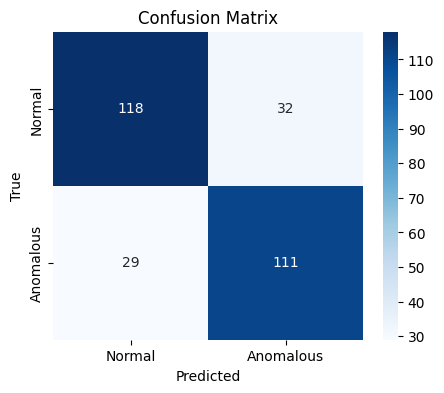

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Normal","Anomalous"], yticklabels=["Normal","Anomalous"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()



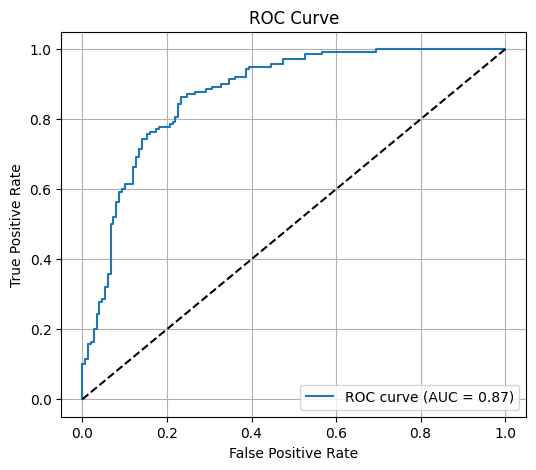

In [40]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()


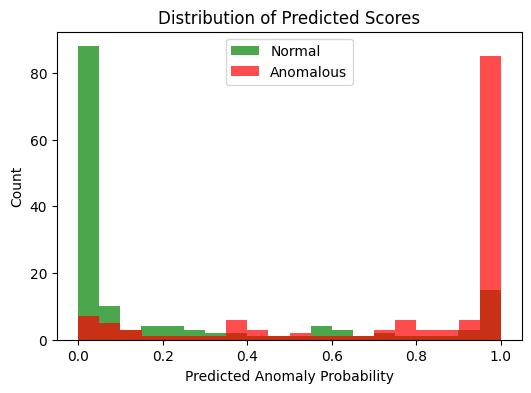

In [41]:
plt.figure(figsize=(6,4))
plt.hist(y_score[y_true==0], bins=20, alpha=0.7, label="Normal", color="g")
plt.hist(y_score[y_true==1], bins=20, alpha=0.7, label="Anomalous", color="r")
plt.xlabel("Predicted Anomaly Probability")
plt.ylabel("Count")
plt.title("Distribution of Predicted Scores")
plt.legend()
plt.show()
